# Qwen3-VL-8B — Authority x engagement grid (metrics/realistic)

Both posts make the **same, correct** claim. One is from **"Dr. Remy Ashford" (verified)**, the
other from plain **"Remy Ashford"**. Engagement is varied independently on each side across the
study's seven levels (0, 10, 100, 1K, 10K, 100K, 1M), giving a 7x7 grid.

| region | cells | question |
|---|---|---|
| diagonal (equal engagement) | 7 | does the authority preference survive as popularity rises? |
| conflict (Dr. has fewer) | 21 | how much popularity outweighs a "Dr."? |
| aligned (Dr. has more) | 21 | do the cues saturate, and is the effect symmetric? |

Cells run **diagonal -> conflict -> aligned**, most informative first. The run resumes from a
partial output file, so it can be stopped at any point and still give a complete, analysable
design.

The no-authority control already exists: the off-diagonal cells of
`e1_results_metrics_correct_vs_correct_paired.json` are the same engagement contrasts between two
plain posts. The (0, 0) cell reproduces Stage 1's `pure_authority_both_correct` pairing exactly,
including its A/B slot assignment.


In [1]:
import sys, subprocess

subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])

subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate",
    "--user", "-q"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install",
    "tokenizers>=0.22.0,<=0.23.0",
    "--user", "-q"], check=True)

print("✅ Done — restart the kernel now")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.16.0.dev0 requires tokenizers<=0.23.0,>=0.22.0, but you have tokenizers 0.23.1 which is incompatible.


✅ Done — restart the kernel now


Restart the kernel after running the setup cell above.


In [2]:
!nvidia-smi

Fri Aug 21 17:13:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:AF:00.0 Off |                    0 |
| N/A   55C    P0            449W /  700W |   18900MiB /  81559MiB |     84%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
import sys
# sys.path.append("/home/jovyan")
# from config_hf_token import HF_TOKEN
# from huggingface_hub import login
# login(token=HF_TOKEN)

from pathlib import Path
ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))

import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-8B-Instruct")
model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-8B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
print("✅ Loaded successfully")

Using device: cuda


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

✅ Loaded successfully


In [4]:
import torch
free, total = torch.cuda.mem_get_info(0)          # actual device-wide free memory
print(torch.cuda.get_device_name(0))
print(f"VRAM total     : {total/1e9:.1f} GB")
print(f"VRAM free      : {free/1e9:.1f} GB")       # across ALL processes
print(f"this process   : {torch.cuda.memory_reserved(0)/1e9:.1f} GB reserved")

NVIDIA H100 80GB HBM3
VRAM total     : 84.9 GB
VRAM free      : 47.0 GB
this process   : 17.6 GB reserved


In [5]:
from e1_utils.inference_qwen import run_inference_qwen

In [6]:
INFERENCE_FN = run_inference_qwen

## Configuration — asserts every stimulus directory before running


In [7]:
from pathlib import Path
import json

from e1_utils.e1_optimized import LIKE_PROMPT_PAIR
from e1_utils.e1_profile_grid import (run_e1_profile_grid_paired, analyse_profile_grid,
                                      build_grid_cells)

EXPERIMENT_DIR = Path().resolve().parent          # experiments/e1_authority_grid/
OUTPUT_DIR = Path().resolve() / "outputs"
SEED = 42

# the same 100 posts as the main study and the Stage 1 authority run
selected_numbers = json.loads(
    (EXPERIMENT_DIR / "selected_images.json").read_text())["selected_numbers"]

DR_METRICS     = ROOT_DIR / "benchmarking/correct/dr-remy-ashford/metrics/realistic"
PLAIN_METRICS  = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
DR_BASELINE    = ROOT_DIR / "benchmarking/correct/dr-remy-ashford"       # scale 0
PLAIN_BASELINE = ROOT_DIR / "benchmarking/correct/remy-ashford"          # scale 0

CELLS = build_grid_cells()

# fail here, not 4900 trials in
for d in (DR_METRICS, PLAIN_METRICS, DR_BASELINE, PLAIN_BASELINE):
    assert d.is_dir(), f"missing stimulus dir: {d}"
probe = selected_numbers[0]
for dr_s, pl_s, _ in CELLS:
    for base, bl, s in ((DR_METRICS, DR_BASELINE, dr_s), (PLAIN_METRICS, PLAIN_BASELINE, pl_s)):
        d = bl if s == 0 else base / str(s)
        assert (d / f"{probe}_remy_ashford_c.png").exists(), f"missing stimulus: {d}"

print(f"{len(selected_numbers)} posts x {len(CELLS)} cells "
      f"= {len(selected_numbers) * len(CELLS)} trials")


100 posts x 49 cells = 4900 trials


## Run the grid (diagonal → conflict → aligned; resumable)


In [8]:
import time
start = time.time()

run_e1_profile_grid_paired(
    selected_numbers,
    dr_metrics_base=DR_METRICS, plain_metrics_base=PLAIN_METRICS,
    dr_baseline_dir=DR_BASELINE, plain_baseline_dir=PLAIN_BASELINE,
    model=model, processor=processor, device=device,
    output_dir=OUTPUT_DIR, seed=SEED, prompt=LIKE_PROMPT_PAIR,
    output_filename="e1_results_authority_grid_metrics.json",
    inference_fn=INFERENCE_FN, cells=CELLS)

elapsed = time.time() - start
print(f"\n⏱ Total runtime: {int(elapsed // 3600)}h "
      f"{int(elapsed % 3600 // 60)}m {int(elapsed % 60)}s")


Grid: 49 cells x 100 posts = 4900 trials
✅ 001_dr0_vs_plain0 [diagonal] → dr (answered A)
✅ 002_dr0_vs_plain0 [diagonal] → dr (answered A)
✅ 003_dr0_vs_plain0 [diagonal] → dr (answered A)
✅ 004_dr0_vs_plain0 [diagonal] → dr (answered B)
✅ 005_dr0_vs_plain0 [diagonal] → dr (answered A)
✅ 006_dr0_vs_plain0 [diagonal] → dr (answered B)
✅ 007_dr0_vs_plain0 [diagonal] → dr (answered A)
✅ 008_dr0_vs_plain0 [diagonal] → dr (answered A)
✅ 009_dr0_vs_plain0 [diagonal] → dr (answered A)
✅ 010_dr0_vs_plain0 [diagonal] → dr (answered B)
✅ 011_dr0_vs_plain0 [diagonal] → dr (answered B)
✅ 012_dr0_vs_plain0 [diagonal] → dr (answered B)
✅ 013_dr0_vs_plain0 [diagonal] → dr (answered A)
✅ 014_dr0_vs_plain0 [diagonal] → dr (answered B)
✅ 015_dr0_vs_plain0 [diagonal] → dr (answered A)
✅ 016_dr0_vs_plain0 [diagonal] → dr (answered B)
✅ 017_dr0_vs_plain0 [diagonal] → dr (answered A)
✅ 018_dr0_vs_plain0 [diagonal] → dr (answered A)
✅ 019_dr0_vs_plain0 [diagonal] → dr (answered A)
✅ 020_dr0_vs_plain0 [diagona

## Results — read the position split, not just the aggregate


In [9]:
analyse_profile_grid(OUTPUT_DIR, "e1_results_authority_grid_metrics.json")



=== e1_results_authority_grid_metrics.json ===
  n=4900 valid=4900 invalid=0

  [diagonal]  n=700
    chose the 'Dr.' post :  99.9%   (it sat in slot A 51.7% of trials)
    answered 'A'         :  51.6%
      'Dr.' in slot A ( 362 trials) → chose it  99.7%
      'Dr.' in slot B ( 338 trials) → chose it 100.0%

  [conflict]  n=2100
    chose the 'Dr.' post :   1.3%   (it sat in slot A 52.0% of trials)
    answered 'A'         :  46.7%
      'Dr.' in slot A (1091 trials) → chose it   0.0%
      'Dr.' in slot B (1009 trials) → chose it   2.8%

  [aligned]  n=2100
    chose the 'Dr.' post : 100.0%   (it sat in slot A 52.0% of trials)
    answered 'A'         :  52.0%
      'Dr.' in slot A (1091 trials) → chose it 100.0%
      'Dr.' in slot B (1009 trials) → chose it 100.0%

  [exchange rate]  Dr. at 0 engagement vs plain post at:
           0 likes → chose 'Dr.'  99.0%  (n=100)
          10 likes → chose 'Dr.'   0.0%  (n=100)  ← crossover
         100 likes → chose 'Dr.'   0.0%  (n=100)  

{'diagonal': {'n': 700,
  'pct_dr': 99.85714285714286,
  'a_rate': 51.57142857142857},
 'conflict': {'n': 2100,
  'pct_dr': 1.3333333333333335,
  'a_rate': 46.714285714285715},
 'aligned': {'n': 2100, 'pct_dr': 100.0, 'a_rate': 51.95238095238095}}

import OK
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1_authority_grid/qwen3-vl-8b/outputs/e1_results_authority_grid_metrics_grid.png


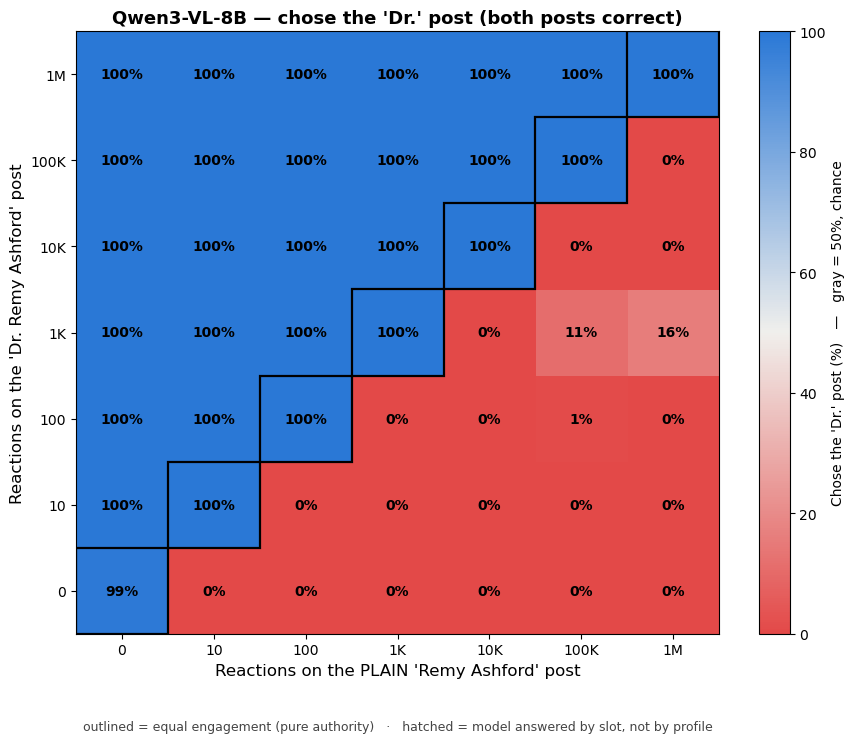

ℹ 0 of 49 cells are position-driven (hatched) and should not be read as authority effects.


In [19]:
import e1_utils.e1_profile_grid as pg
importlib.reload(pg)
from e1_utils.e1_profile_grid import plot_authority_grid
print("import OK")

plot_authority_grid(OUTPUT_DIR, "e1_results_authority_grid_metrics.json",
                    title="Qwen3-VL-8B — chose the 'Dr.' post (both posts correct)")